## Import 

In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os 
import shutil 
from PIL import Image

import torch 
import torch.nn as nn
from torch.nn import functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

import time
import psutil
import gc
import sys

import random


## Constant

In [3]:
BASE  = '/kaggle/input/datasets/nasimetemadi/car-damage-detection/CarDD_release/CarDD_SOD'

In [4]:
IMG_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")


Device: cuda


In [5]:
SPLITS = {
    'train': {
        'image': f'{BASE}/CarDD-TR/CarDD-TR-Image',
        'mask' : f'{BASE}/CarDD-TR/CarDD-TR-Mask',
    },
    'val': {
        'image': f'{BASE}/CarDD-VAL/CarDD-VAL-Image',
        'mask' : f'{BASE}/CarDD-VAL/CarDD-VAL-Mask',
    },
    'test': {
        'image': f'{BASE}/CarDD-TE/CarDD-TE-Image',
        'mask' : f'{BASE}/CarDD-TE/CarDD-TE-Mask',
    },
}

In [6]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

In [7]:
NUM_EPOCHS = 30

## Read the data 

In [8]:
for split in ['CarDD-TR', 'CarDD-VAL', 'CarDD-TE']:
    path = os.path.join(BASE, split)
    for subfolder  in  os.listdir(path):
        subfolder_path = os.path.join(path, subfolder)
        if os.path.isdir(subfolder_path):
            n_files = len(os.listdir(subfolder_path))
            print(f"{split}/{subfolder}: {n_files} files")
    print()
    

CarDD-TR/CarDD-TR-Edge: 2816 files
CarDD-TR/CarDD-TR-Mask: 2816 files
CarDD-TR/CarDD-TR-Image: 2816 files

CarDD-VAL/CarDD-VAL-Image: 810 files
CarDD-VAL/CarDD-VAL-Edge: 810 files
CarDD-VAL/CarDD-VAL-Mask: 810 files

CarDD-TE/CarDD-TE-Mask: 374 files
CarDD-TE/CarDD-TE-Edge: 374 files
CarDD-TE/CarDD-TE-Image: 374 files



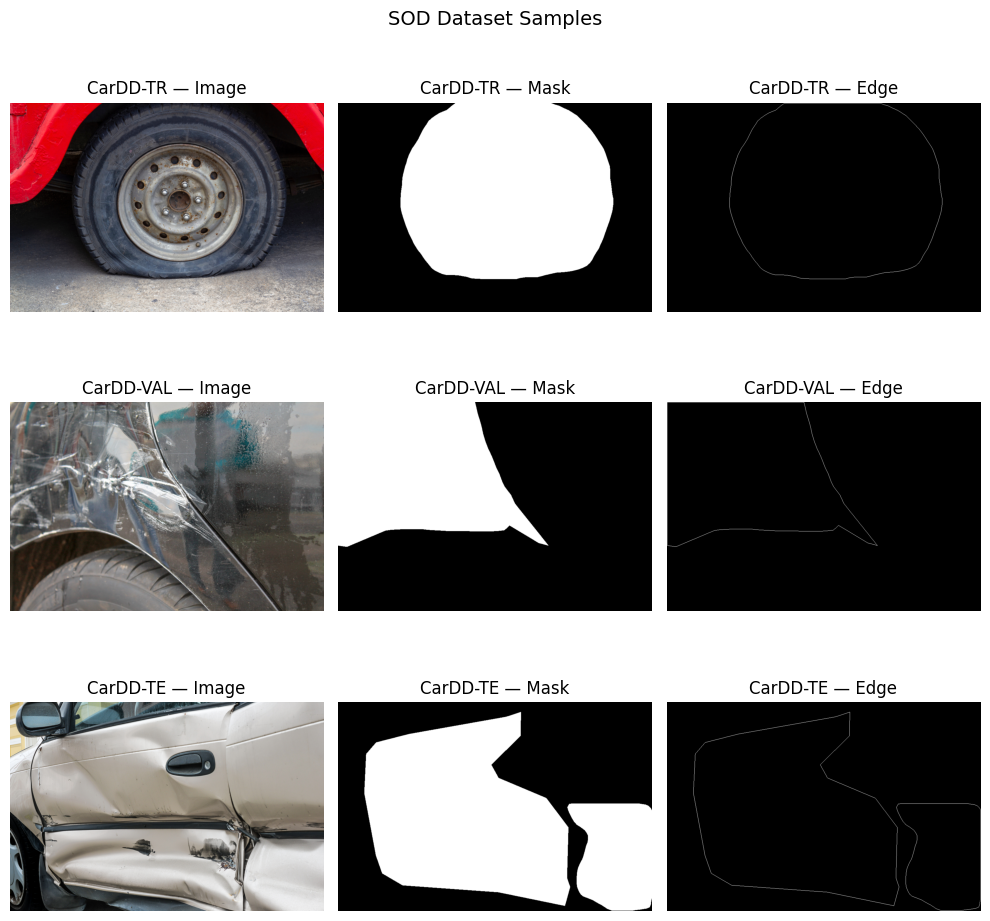

Mask shape  : (668, 1000)
Mask dtype  : uint8
Mask values : min=0, max=255
Unique vals : [  0 255]


In [9]:
splits_dirs = [
    ('CarDD-TR',  'CarDD-TR-Image',  'CarDD-TR-Mask',  'CarDD-TR-Edge'),
    ('CarDD-VAL', 'CarDD-VAL-Image', 'CarDD-VAL-Mask', 'CarDD-VAL-Edge'),
    ('CarDD-TE',  'CarDD-TE-Image',  'CarDD-TE-Mask',  'CarDD-TE-Edge'),
]


fig, axes = plt.subplots(3,3,figsize=(10,10))


for row,(split, img_dir, mask_dir, edge_dir) in enumerate(splits_dirs):
    img_files = os.path.join(BASE, split, img_dir)
    fname     = os.listdir(img_files)[0]
    mask_name = fname.replace('jpg', 'png')

    img  = Image.open(os.path.join(BASE,split,img_dir,fname)).convert('RGB')
    mask = Image.open(os.path.join(BASE,split,mask_dir, mask_name)).convert('L') 
    edge = Image.open(os.path.join(BASE,split,edge_dir, mask_name)).convert('L')


    axes[row][0].imshow(img)
    axes[row][0].set_title(f'{split} — Image',)
    axes[row][0].axis('off')

    axes[row][1].imshow(mask, cmap='gray')
    axes[row][1].set_title(f'{split} — Mask', )
    axes[row][1].axis('off')

    axes[row][2].imshow(edge, cmap='gray')
    axes[row][2].set_title(f'{split} — Edge', )
    axes[row][2].axis('off')

plt.suptitle('SOD Dataset Samples', fontsize=14, )

    


plt.savefig('sod_samples.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

sample_mask = np.array(mask)
print(f"Mask shape  : {sample_mask.shape}")
print(f"Mask dtype  : {sample_mask.dtype}")
print(f"Mask values : min={sample_mask.min()}, max={sample_mask.max()}")
print(f"Unique vals : {np.unique(sample_mask)}")



## Load the data 

In [10]:
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

mask_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])



In [11]:
class SODDataset(Dataset):
    def __init__(self, split, img_transform= None, mask_transform= None):
        self.img_dir        = SPLITS[split]['image']
        self.mask_dir       = SPLITS[split]['mask']
        self.img_transform  = img_transform
        self.mask_transform = mask_transform

        self.images = sorted(os.listdir(self.img_dir))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        fname     = self.images[idx]
        mask_name = fname.replace('.jpg', '.png')

        img       = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        mask      = Image.open(os.path.join(self.mask_dir, mask_name)).convert('L')


        if self.img_transform:
            img = self.img_transform(img)
        if self.mask_transform:
            mask = self.mask_transform(mask)
        mask = (mask>0.5).float()
        return img, mask
        

In [12]:
train_dataset = SODDataset('train', img_transform, mask_transform)
val_dataset   = SODDataset('val'  , img_transform, mask_transform)
test_dataset  = SODDataset('test' , img_transform, mask_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0, pin_memory=False,persistent_workers=False)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0, pin_memory=False,persistent_workers=False)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0, pin_memory=False,persistent_workers=False) 

In [13]:
imgs, mask = next(iter(train_loader))
print(f'Image batch shape: {imgs.shape} ')
print(f'Mask batch shape : {mask.shape} ')
print(f'Mask unique value: {mask.unique()} ')
print(f"\nTrain size : {len(train_dataset)}")
print(f"Val size   : {len(val_dataset)}")
print(f"Test size  : {len(test_dataset)}")

Image batch shape: torch.Size([4, 3, 256, 256]) 
Mask batch shape : torch.Size([4, 1, 256, 256]) 
Mask unique value: tensor([0., 1.]) 

Train size : 2816
Val size   : 810
Test size  : 374


## Create the model 

In [14]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding= dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
        

In [15]:
class RSU(nn.Module):
    def __init__(self, in_ch, mid_ch, out_ch, depth=7):
        super().__init__()
        self.depth  = depth

        # input conv
        self.conv_in = ConvBNReLU(in_ch, out_ch)

        # encoder path
        self.enc = nn.ModuleList()
        self.pool= nn.ModuleList()
        for i in range(depth - 1):
            self.enc.append(ConvBNReLU(out_ch if i==0 else mid_ch, mid_ch))
            self.pool.append(nn.MaxPool2d(2, 2))

        # bottleneck (dilated conv — no pooling)
        self.bottleneck = ConvBNReLU(mid_ch, mid_ch, dilation=2)

        # decoder path
        self.dec = nn.ModuleList()
        for i in range(depth - 1):
            in_c = mid_ch * 2
            self.dec.append(ConvBNReLU(in_c, mid_ch if i < depth-2 else out_ch))

    def forward(self, x):
        x_in = self.conv_in(x)

        # encode
        enc_feats = []
        xe = x_in
        for i in range(self.depth - 1):
            xe = self.enc[i](xe)
            enc_feats.append(xe)
            xe = self.pool[i](xe)

        # bottleneck
        xd = self.bottleneck(xe)

        # decode
        for i in range(self.depth - 2, -1, -1):
            xd = F.interpolate(xd, size=enc_feats[i].shape[2:],
                               mode='bilinear', align_corners=False)
            xd = self.dec[self.depth - 2 - i](
                torch.cat([xd, enc_feats[i]], dim=1))
        # ✅ explicitly delete enc_feats after use
        del enc_feats

        return xd + x_in

In [16]:
class U2Net(nn.Module):
    def __init__(self):
        super().__init__()

        #encode stage
        self.enc1 = RSU(in_ch=3   ,mid_ch=16,  out_ch=64, depth=7)
        self.enc2 = RSU(in_ch=64  ,mid_ch=16,  out_ch=64, depth=6)
        self.enc3 = RSU(in_ch=64  ,mid_ch=16,  out_ch=64, depth=5)
        self.enc4 = RSU(in_ch=64  ,mid_ch=16,  out_ch=64, depth=4)
        self.enc5 = RSU(in_ch=64  ,mid_ch=16,  out_ch=64, depth=4)
        #bottleneck
        self.bottleneck = RSU(64, 16, 64, depth=4)
        # decode stage 
        self.dec5 = RSU(in_ch=128 ,mid_ch=16, out_ch=64, depth=4)
        self.dec4 = RSU(in_ch=128 ,mid_ch=16, out_ch=64, depth=4)
        self.dec3 = RSU(in_ch=128 ,mid_ch=16, out_ch=64, depth=5)
        self.dec2 = RSU(in_ch=128 ,mid_ch=16, out_ch=64, depth=6)
        self.dec1 = RSU(in_ch=128 ,mid_ch=16, out_ch=64, depth=7)

        # pooling 
        self.pool = nn.MaxPool2d(2,2)

        
        # side output heads (one per stage)
        self.side1 = nn.Conv2d(64,  1, 3, padding=1)
        self.side2 = nn.Conv2d(64,  1, 3, padding=1)
        self.side3 = nn.Conv2d(64, 1, 3, padding=1)
        self.side4 = nn.Conv2d(64, 1, 3, padding=1)
        self.side5 = nn.Conv2d(64, 1, 3, padding=1)
        self.side6 = nn.Conv2d(64, 1, 3, padding=1)



        # final fusion
        self.fuse = nn.Conv2d(6,1,1)
    def forward(self,x):
        H,W = x.shape[2:]
        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e5 = self.enc5(self.pool(e4))

        # bottleneck
        bn = self.bottleneck(self.pool(e5))

        # decoder
        d5 = self.dec5(torch.cat([F.interpolate(bn, mode='bilinear', size=e5.shape[2:]
                                                ,align_corners=False),e5],dim=1))
        d4 = self.dec4(torch.cat([F.interpolate(d5,mode='bilinear', size=e4.shape[2:]
                                               ,align_corners=False),e4],dim=1))
        d3 = self.dec3(torch.cat([F.interpolate(d4,mode='bilinear', size=e3.shape[2:]
                                               ,align_corners=False),e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3,mode='bilinear', size=e2.shape[2:]
                                               ,align_corners=False),e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2,mode='bilinear', size=e1.shape[2:]
                                               ,align_corners=False),e1], dim=1))
        # side outputs — all resized to input size
        
        s1 = F.interpolate(self.side1(d1), size=(H,W),
                           mode='bilinear', align_corners=False)
        s2 = F.interpolate(self.side2(d2), size=(H,W),
                           mode='bilinear', align_corners=False)
        s3 = F.interpolate(self.side3(d3), size=(H,W),
                           mode='bilinear', align_corners=False)
        s4 = F.interpolate(self.side4(d4), size=(H,W),
                           mode='bilinear', align_corners=False)
        s5 = F.interpolate(self.side5(d5), size=(H,W),
                           mode='bilinear', align_corners=False)
        s6 = F.interpolate(self.side6(bn), size=(H,W),
                           mode='bilinear', align_corners=False)

        # fuse all side outputs
        fused = self.fuse(torch.cat([s1,s2,s3,s4,s5,s6], dim=1))

        # return all outputs (for deep supervision loss)
        return fused, s1, s2, s3, s4, s5, s6
        
        

In [17]:
model = U2Net().to(DEVICE)

In [18]:
model.eval()
with torch.no_grad():
    sample = torch.randn(2, 3, 352, 352).to(DEVICE)
    outputs = model(sample)

print(f"Number of outputs : {len(outputs)}")
print(f"Fused output shape: {outputs[0].shape}")   # [2, 1, 352, 352]
print(f"Side output shape : {outputs[1].shape}")   # [2, 1, 352, 352]

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters  : {total_params:,}")

Number of outputs : 7
Fused output shape: torch.Size([2, 1, 352, 352])
Side output shape : torch.Size([2, 1, 352, 352])

Total parameters  : 1,128,333


## Model loss and optimizer

In [19]:
def bce_loss(pred,target):
    return nn.BCEWithLogitsLoss()(pred, target)

def u2net_loss(outputs, target):
    fused, s1,s2,s3,s4,s5,s6 = outputs
    loss = bce_loss(fused, target)
    loss+= bce_loss(s1,    target)
    loss+= bce_loss(s2,    target)
    loss+= bce_loss(s3,    target)
    loss+= bce_loss(s4,    target)
    loss+= bce_loss(s5,    target)
    loss+= bce_loss(s6,    target)
    return loss
    
    
    

In [20]:
def compute_mae(pred, target, threshold):
    pred_bin = (torch.sigmoid(pred)>threshold).float()
    return torch.abs(pred_bin-target).mean().item()
    
def compute_f_measure(pred, target, threshold, beta):
    pred_bin = (torch.sigmoid(pred)>threshold).float()

    tp = (pred_bin*target).sum()
    fp = (pred_bin* (1-target)).sum()
    fn = ((1-pred_bin)* target).sum()

    precision = tp / (tp+ fp+ 1e-8)
    recall    = tp / (tp+ fn+ 1e-8)
    f         = (1+beta) * precision* recall /(beta*precision+recall+1e-8)
    return f.item()
    

In [21]:
optimizer = Adam(model.parameters(), lr= 1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

In [22]:
def train_one_ropch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs = imgs.float().to(DEVICE)
        masks = masks.float().to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(imgs)
        loss    = u2net_loss(outputs=outputs, target=masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)  # why we need to multiply with number of imgs 
        torch.cuda.empty_cache()
        # print(imgs.size(0), len(loader.dataset))
    gc.collect()  
    return running_loss/len(loader.dataset)

In [23]:
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    mae_scores    = []
    f_scores      = []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs    = imgs.float().to(DEVICE)
            masks   = masks.float().to(DEVICE)
            outputs = model(imgs)
            loss    = u2net_loss(outputs, masks)
            running_loss += loss.item() * imgs.size(0)
            fused = outputs[0]
            mae_scores.append(compute_mae(fused, masks,0.5 ))
            f_scores.append(compute_f_measure(fused, masks, 0.5, 0.3)) 
    avg_loss = running_loss / len(loader.dataset)
    avg_mae  = sum(mae_scores) / len(mae_scores)
    avg_f    = sum(f_scores)   / len(f_scores)
    return avg_loss, avg_mae, avg_f

## training

In [24]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'mae': [], 'f_measure': []}
print(f"\n{'='*65}")
print(f"Training U2-Net on {DEVICE} for {NUM_EPOCHS} epochs")
print(f"{'='*65}\n")
for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss               = train_one_ropch(model, train_loader, optimizer)
    val_loss, mae, f_measure = validate(model, val_loader)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['mae'].append(mae)
    history['f_measure'].append(f_measure)
    elapsed = time.time()-start
    ram = psutil.virtual_memory()
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"| Train Loss: {train_loss:.4f} "
          f"| Val Loss: {val_loss:.4f} "
          f"| MAE: {mae:.4f} "
          f"| F-measure: {f_measure:.4f} "
          f"| Time: {elapsed:.1f}s")
    print(f"  RAM: {ram.used/1024**3:.2f}/{ram.total/1024**3:.2f} GB ({ram.percent}%) "
          f"| GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),'best_u2net.pth' )
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})\n")
print("\n🎉 Training complete!")
print(f"Best val loss : {best_val_loss:.4f}")
    


Training U2-Net on cuda for 30 epochs

Epoch [01/30] | Train Loss: 3.4866 | Val Loss: 3.2677 | MAE: 0.2147 | F-measure: 0.4796 | Time: 357.5s
  RAM: 1.80/31.35 GB (7.2%) | GPU: 0.03 GB
  ✅ Best model saved (val_loss=3.2677)

Epoch [02/30] | Train Loss: 3.2862 | Val Loss: 3.1330 | MAE: 0.1979 | F-measure: 0.5233 | Time: 276.2s
  RAM: 1.81/31.35 GB (7.2%) | GPU: 0.03 GB
  ✅ Best model saved (val_loss=3.1330)

Epoch [03/30] | Train Loss: 3.1488 | Val Loss: 2.9639 | MAE: 0.1820 | F-measure: 0.5700 | Time: 276.8s
  RAM: 1.79/31.35 GB (7.2%) | GPU: 0.03 GB
  ✅ Best model saved (val_loss=2.9639)

Epoch [04/30] | Train Loss: 2.9610 | Val Loss: 2.8909 | MAE: 0.1925 | F-measure: 0.5652 | Time: 275.5s
  RAM: 1.81/31.35 GB (7.2%) | GPU: 0.03 GB
  ✅ Best model saved (val_loss=2.8909)

Epoch [05/30] | Train Loss: 2.7527 | Val Loss: 2.8859 | MAE: 0.1783 | F-measure: 0.5930 | Time: 277.6s
  RAM: 1.80/31.35 GB (7.2%) | GPU: 0.03 GB
  ✅ Best model saved (val_loss=2.8859)

Epoch [06/30] | Train Loss: 2.

In [25]:
# import psutil
# import torch

# # ── RAM (CPU memory) ────────────────────────────────────────────────────
# ram = psutil.virtual_memory()
# print(f"=== RAM ===")
# print(f"Total  : {ram.total/1024**3:.2f} GB")
# print(f"Used   : {ram.used/1024**3:.2f} GB")
# print(f"Free   : {ram.available/1024**3:.2f} GB")
# print(f"Percent: {ram.percent}%")

# # ── GPU memory ───────────────────────────────────────────────────────────
# print(f"\n=== GPU ===")
# print(f"Allocated : {torch.cuda.memory_allocated()/1024**3:.2f} GB")
# print(f"Reserved  : {torch.cuda.memory_reserved()/1024**3:.2f} GB")

# # ── DataLoader workers ───────────────────────────────────────────────────
# print(f"\n=== DataLoader ===")
# print(f"Train num_workers: {train_loader.num_workers}")
# print(f"Batch size       : {train_loader.batch_size}")

In [26]:
# # ── Check if dataset is caching images ──────────────────────────────────
# import sys

# # check size of dataset objects
# print(f"train_dataset size in memory: {sys.getsizeof(train_dataset)} bytes")
# print(f"val_dataset size in memory  : {sys.getsizeof(val_dataset)} bytes")

# # check one sample size
# img, mask = train_dataset[0]
# print(f"\nOne image tensor size: {img.element_size() * img.nelement() / 1024**2:.2f} MB")
# print(f"One mask tensor size : {mask.element_size() * mask.nelement() / 1024**2:.2f} MB")

# # calculate total dataset size
# one_sample_mb = (img.element_size() * img.nelement() +
#                  mask.element_size() * mask.nelement()) / 1024**2
# total_mb = one_sample_mb * len(train_dataset)
# print(f"\nOne sample size      : {one_sample_mb:.2f} MB")
# print(f"Full train set size  : {total_mb/1024:.2f} GB")
# print(f"Full val set size    : {one_sample_mb * len(val_dataset)/1024:.2f} GB")

In [27]:
# # ── Fix: reduce image size further to reduce memory per sample ──────────
# IMG_SIZE = 224  # was 256 → now 224 (saves ~24% per image)

# img_transforms = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),
# ])

# mask_transforms = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
# ])

# # ── Recreate datasets & loaders ──────────────────────────────────────────
# train_dataset = SODDataset('train', img_transforms, mask_transforms)
# val_dataset   = SODDataset('val',   img_transforms, mask_transforms)
# test_dataset  = SODDataset('test',  img_transforms, mask_transforms)

# train_loader = DataLoader(train_dataset, batch_size=4,
#                           shuffle=True,
#                           num_workers=0,
#                           pin_memory=False,
#                           persistent_workers=False)  # ✅ don't keep workers alive

# val_loader   = DataLoader(val_dataset, batch_size=4,
#                           shuffle=False,
#                           num_workers=0,
#                           pin_memory=False,
#                           persistent_workers=False)

# # ── Verify new sample size ───────────────────────────────────────────────
# img, mask = train_dataset[0]
# one_sample_mb = (img.element_size() * img.nelement() +
#                  mask.element_size() * mask.nelement()) / 1024**2
# print(f"New sample size    : {one_sample_mb:.2f} MB")
# print(f"New train set size : {one_sample_mb * len(train_dataset)/1024:.2f} GB")
# print(f"New val set size   : {one_sample_mb * len(val_dataset)/1024:.2f} GB")


In [28]:
# def get_ram():
#     return psutil.virtual_memory().used / 1024**3

# print(f"Start                : {get_ram():.2f} GB")

# # ── One batch ────────────────────────────────────────────────────────────
# imgs, masks = next(iter(train_loader))
# print(f"After loading batch  : {get_ram():.2f} GB")

# imgs  = imgs.float().to(DEVICE)
# masks = masks.float().to(DEVICE)
# print(f"After .to(DEVICE)    : {get_ram():.2f} GB")

# outputs = model(imgs)
# print(f"After forward pass   : {get_ram():.2f} GB")

# loss = u2net_loss(outputs, masks)
# print(f"After loss           : {get_ram():.2f} GB")

# loss.backward()
# print(f"After backward       : {get_ram():.2f} GB")

# optimizer.step()
# print(f"After optimizer step : {get_ram():.2f} GB")

# del imgs, masks, outputs, loss
# gc.collect()
# torch.cuda.empty_cache()
# print(f"After cleanup        : {get_ram():.2f} GB")

# # ── Full epoch ───────────────────────────────────────────────────────────
# print(f"\nRunning full epoch...")
# for i, (imgs, masks) in enumerate(train_loader):
#     imgs  = imgs.float().to(DEVICE)
#     masks = masks.float().to(DEVICE)
#     optimizer.zero_grad(set_to_none=True)
#     outputs = model(imgs)
#     loss    = u2net_loss(outputs, masks)
#     loss.backward()
#     optimizer.step()
#     for out in outputs:
#         out.detach_()
#     del imgs, masks, outputs, loss

#     if i % 100 == 0:
#         print(f"  Batch {i:03d} | RAM: {get_ram():.2f} GB")

# gc.collect()
# torch.cuda.empty_cache()
# print(f"\nAfter full epoch     : {get_ram():.2f} GB")

In [29]:
# import psutil, gc

# def get_ram():
#     return psutil.virtual_memory().used / 1024**3

# print(f"Start: {get_ram():.2f} GB")

# for i, (imgs, masks) in enumerate(train_loader):
#     imgs  = imgs.float().to(DEVICE)
#     masks = masks.float().to(DEVICE)
#     optimizer.zero_grad(set_to_none=True)
#     outputs = model(imgs)
#     loss    = u2net_loss(outputs, masks)
#     loss.backward()
#     optimizer.step()
#     del imgs, masks, outputs, loss

#     if i % 50 == 0:
#         gc.collect()
#         torch.cuda.empty_cache()
#         print(f"  Batch {i:03d} | RAM: {get_ram():.2f} GB")

# gc.collect()
# torch.cuda.empty_cache()
# print(f"After full epoch: {get_ram():.2f} GB")

In [30]:
# import torch
# import gc

# def check_memory():
#     # ── All tensors in memory ───────────────────────────────────────────
#     tensor_stats = {}
#     for obj in gc.get_objects():
#         try:
#             if torch.is_tensor(obj):
#                 key = f"{obj.dtype} {list(obj.shape)}"
#                 if key not in tensor_stats:
#                     tensor_stats[key] = {'count': 0, 'mb': 0}
#                 tensor_stats[key]['count'] += 1
#                 tensor_stats[key]['mb'] += obj.element_size() * obj.nelement() / 1024**2
#         except:
#             pass

#     # sort by memory usage
#     sorted_stats = sorted(tensor_stats.items(),
#                           key=lambda x: x[1]['mb'], reverse=True)

#     print(f"{'Shape':<40} {'Count':>8} {'MB':>10}")
#     print("-" * 60)
#     total_mb = 0
#     for key, val in sorted_stats[:20]:  # top 20
#         print(f"{key:<40} {val['count']:>8} {val['mb']:>10.2f}")
#         total_mb += val['mb']
#     print("-" * 60)
#     print(f"{'Total (top 20)':<40} {'':>8} {total_mb:>10.2f} MB")

# # ── Check before training ────────────────────────────────────────────────
# print("=== BEFORE TRAINING ===")
# check_memory()

# # ── Run 100 batches ──────────────────────────────────────────────────────
# for i, (imgs, masks) in enumerate(train_loader):
#     if i >= 100:
#         break
#     imgs  = imgs.float().to(DEVICE)
#     masks = masks.float().to(DEVICE)
#     optimizer.zero_grad(set_to_none=True)
#     outputs = model(imgs)
#     loss    = u2net_loss(outputs, masks)
#     loss.backward()
#     optimizer.step()
#     del imgs, masks, outputs, loss

# gc.collect()
# torch.cuda.empty_cache()

# # ── Check after 100 batches ──────────────────────────────────────────────
# print("\n=== AFTER 100 BATCHES ===")
# check_memory()

In [31]:
# # ── Rebuild model WITHOUT DataParallel ──────────────────────────────────
# del model
# gc.collect()
# torch.cuda.empty_cache()

# model = U2Net().to(DEVICE)

# # verify no DataParallel
# print(f"Model type: {type(model)}")
# print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# gc.collect()
# torch.cuda.empty_cache()

# # ── Verify memory is stable ──────────────────────────────────────────────
# print(f"\nRAM after rebuild: {psutil.virtual_memory().used/1024**3:.2f} GB")

# for i, (imgs, masks) in enumerate(train_loader):
#     if i >= 200:
#         break
#     imgs  = imgs.float().to(DEVICE)
#     masks = masks.float().to(DEVICE)
#     optimizer.zero_grad(set_to_none=True)
#     outputs = model(imgs)
#     loss    = u2net_loss(outputs, masks)
#     loss.backward()
#     optimizer.step()
#     del imgs, masks, outputs, loss

#     if i % 50 == 0:
#         gc.collect()
#         torch.cuda.empty_cache()
#         print(f"  Batch {i:03d} | RAM: {psutil.virtual_memory().used/1024**3:.2f} GB")

# print(f"\nAfter 200 batches: {psutil.virtual_memory().used/1024**3:.2f} GB")

## Visualization the training 

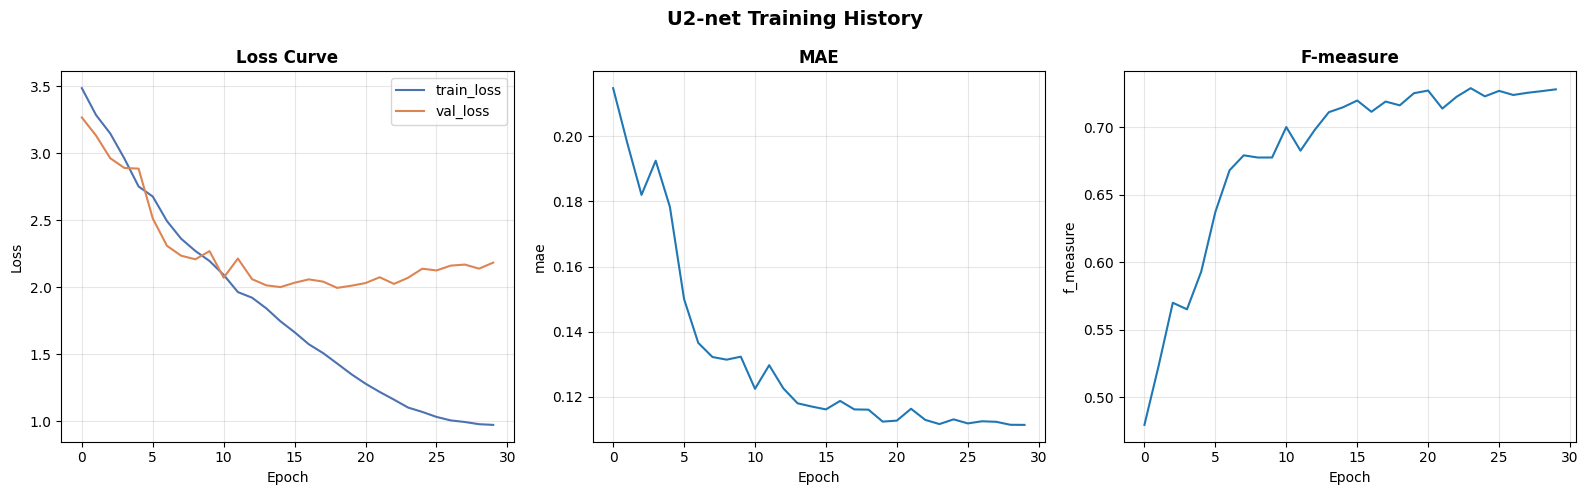

In [46]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
axes[0].plot(history['train_loss'], label='train_loss', color='#4C72B0')
axes[0].plot(history['val_loss'], label='val_loss', color='#DD8452')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['mae'])
axes[1].set_title('MAE',fontweight='bold' )
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mae')
axes[1].grid(alpha=0.3)

axes[2].plot(history['f_measure'])
axes[2].set_title('F-measure',fontweight='bold' )
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('f_measure')
axes[2].grid(alpha=0.3)

plt.suptitle('U2-net Training History', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('sod_training_curves.png', dpi=150,bbox_inches='tight')

plt.show()


In [33]:
model.load_state_dict(torch.load('best_u2net.pth'))
model.eval()

U2Net(
  (enc1): RSU(
    (conv_in): ConvBNReLU(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (enc): ModuleList(
      (0): ConvBNReLU(
        (conv): Sequential(
          (0): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (1-5): 5 x ConvBNReLU(
        (conv): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
    )
    (pool): ModuleList(
      (0-5): 6 x MaxPool2d(kernel_size=2, stride=2, pad

## Evaluation

In [43]:
test_img_dirs = SPLITS['test']['image']
test_mask_dirs = SPLITS['test']['mask']

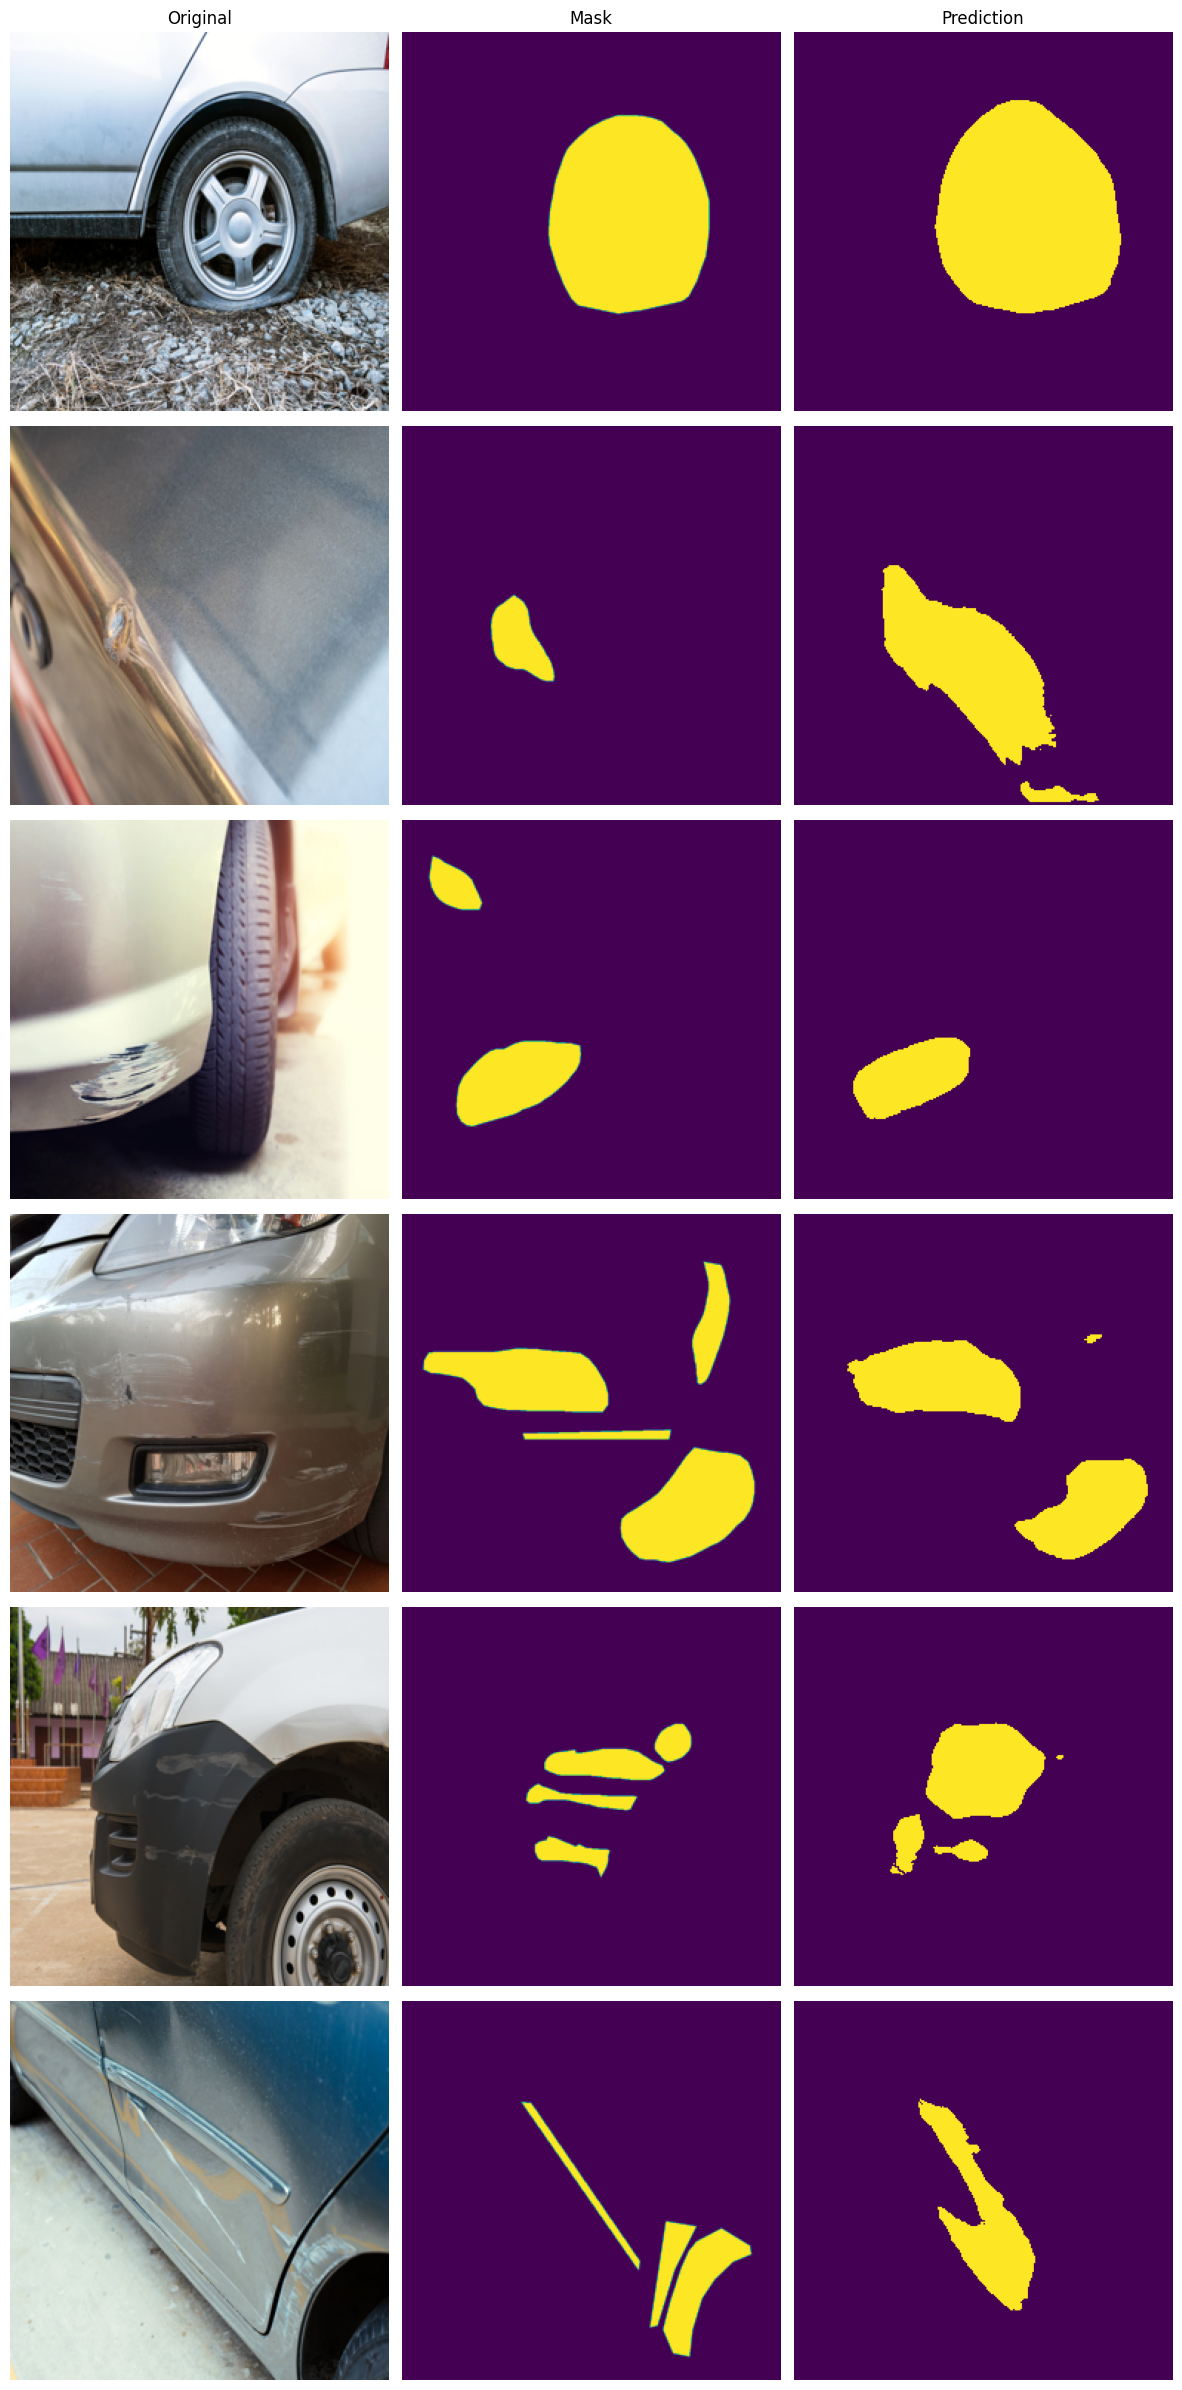

In [53]:
samples = random.sample(os.listdir(test_img_dirs), 6)
col_titles = ['Original', 'Mask', 'Prediction']
fig, axes = plt.subplots(6,3,figsize=(12,24))
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title)
for row, fname in enumerate(samples):
    mask_fname = fname.replace('.jpg', '.png')
    img  = Image.open(os.path.join(test_img_dirs, fname)).convert('RGB')
    mask = Image.open(os.path.join(test_mask_dirs, mask_fname)).convert('L')

    tensor_img = img_transform(img).unsqueeze(0).float().to(DEVICE)
    
    with torch.no_grad():
        outputs = model(tensor_img)
        pred    = torch.sigmoid(outputs[0])
        pred    = (pred> 0.5).float()
        pred_np = pred.squeeze().cpu().numpy()
        
    img_np  = np.array(img.resize((IMG_SIZE,IMG_SIZE))) 
    mask_np = np.array(mask.resize((IMG_SIZE, IMG_SIZE)))
    pred_256 = (pred_np * 255).astype(np.uint8)
    pred_256 = np.array(Image.fromarray(pred_256).resize((IMG_SIZE,IMG_SIZE)))

    # showing the original
    axes[row][0].imshow(img_np)
    axes[row][0].axis('off')
    #showing the mask
    axes[row][1].imshow(mask_np)
    axes[row][1].axis('off')
    #showing prediction
    axes[row][2].imshow(pred_256)
    axes[row][2].axis('off')

        
        
plt.tight_layout()        

plt.grid(alpha=0.3)


In [54]:
print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)

test_mae    = []
test_f      = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.float().to(DEVICE)
        masks = masks.float().to(DEVICE)

        outputs = model(imgs)
        fused   = outputs[0]

        test_mae.append(compute_mae(fused, masks, 0.5))
        test_f.append(compute_f_measure(fused, masks, 0.5, 0.3))

        del imgs, masks, outputs, fused
print(f"MAE       : {sum(test_mae)/len(test_mae):.4f}  (lower = better)")
print(f"F-measure : {sum(test_f)/len(test_f):.4f}  (higher = better)")
print("=" * 50)

TEST SET EVALUATION
MAE       : 0.1230  (lower = better)
F-measure : 0.7120  (higher = better)
